In [27]:
# lotka_volterra_experiment.py
"""Do a single numerical experiment from start to finish."""

import os
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt

import opinf

import utils
import config_lotka_volterra as config
import step1_generate_data as step1
import step1_5_estimate_priors as step1_5
import step2_fitgps as step2
import step3_estimate as step3
import step4_plot as step4
import plots as extra_plots
from scipy.interpolate import CubicSpline

def one_run(
    training_span: tuple[float, float],
    num_samples: int,
    noiselevel: float,
    num_regression_points: int,
    kernel:str,
    gp_regularizer: float = 1e-8,
    ndraws: int = 100,
    prior: bool = False,
    exportto: str = None,
    openonsave: bool = True,
    ensemble: bool = False,
    custom_save: str = "none",
    verbose: bool = False,
    plots: bool = False,
    no_seed: bool = False,
    interpolate: bool = True,
):
    r"""Do a single trial from start to finish (do not save intermediate data).

    Parameters
    ----------
    training_span : (float, float)
        Time domain over which to sample solution data.
    num_samples : int > 0
        Number of snapshots to sample.
    noiselevel : float >= 0
        Percentage of noise applied to the training snapshots.
    num_regression_points : int > 0
        Number of points at which to evaluate the GP state and derivative
        estimates.
    gp_regularizer : float >= 0
        Regularization hyperparameter for the GP inference in inverting for
        the least-squares weight matrix.
    ndraws : int
        Number of draws from the posterior distribution.
    exportto : str
        If given, write experiment data to an HDF5 files with ``exportto`` as
        the prefix.
    openonsave : bool
        If ``True`` (default), open figures as they are created.
    """
    if not no_seed: # If we don't pass in "no_seed" then we give a seed
        seed = 21092023
        print(f"Set seed: {seed}")
        np.random.seed(seed)
    else:
        print(f"No seed being used")

    print(kernel)
    if custom_save != "none":
        # Expand user (~) and construct full save path
        custom_save = os.path.expanduser(custom_save)
        save = f"{custom_save}/{num_samples}_{noiselevel}"

        # Create directory if it doesn't exist
        os.makedirs(save, exist_ok=True)
        print(f"Save directory ready at: {save}")
    else:
        save = config.figures_path()
    

    # Report on experimental scenario.
    utils.summarize_experiment(
        training_span=training_span,
        num_samples=num_samples,
        noiselevel=noiselevel,
        num_regression_points=num_regression_points,
        gp_regularizer=gp_regularizer,
        opinf_regularizer=None,
        ndraws=ndraws,
    )

    # Step 1: Generate data ---------------------------------------------------
    sampler = step1.TrajectorySampler(
        training_span=training_span,
        num_samples=num_samples,
        noiselevel=noiselevel,
        num_regression_points=num_regression_points,
        synced=False,
        integersonly=False,
        config=config
    )

    (
        truthmodel,
        time_domain_prediction,
        true_states,
        time_domains_sampled,
        snapshots_sampled,
    ) = sampler.sample()
    true_parameters = np.copy(truthmodel.parameters)

    # Step 1.5: Estimate period of data (Optional)
    period_length_priors = None
    if prior:
        # Try making y larger?
        snapshots_sampled_larger = (snapshots_sampled[0]*10, snapshots_sampled[1]*10)
        period_length_priors = step1_5.estimate_period(
            t=time_domains_sampled,
            y=snapshots_sampled_larger,
            plow=.5,
            phigh=20,
        )
        if plots:
            extra_plots.period_length_prior(period_length_priors,time_domains_sampled,snapshots_sampled,save)
    
    # Augment data with extra training samples
    new_times = []
    new_states = []
    if prior and interpolate:
        training_span = (0,max(period_length_priors[0][0]*2, period_length_priors[1][0]*2))
        print(f"updated training span to {training_span}")
        mean_period, sttdev_period = period_length_priors
        periods = [prior[0]*2 for prior in period_length_priors]
        new_time, new_state = densify_time_series(time_domains_sampled, snapshots_sampled, periods, 2)
    
    time_domains_sampled = new_time
    snapshots_sampled = new_state
        # plt.plot(time_domains_sampled, snapshots_sampled)
        # plt.plot(new_time,new_state)
        # plt.plot()
        # visualize_densification(time_domains_sampled, snapshots_sampled, new_time, new_state)
        # return
        # n_vars, n_points = np.array(time_domains_sampled).shape
        # new_time = []
        # new_state = []

        # for i in range(n_vars):
        #     t = time_domains_sampled[i]
        #     y = snapshots_sampled[i]
        #     T = period_length_priors[i][0]  # mean period
        #     T = T*2

        #     total_time = t[-1] - t[0]
        #     total_periods = total_time / T
        #     points_per_period = 50
        #     total_new_points = int(points_per_period * total_periods)
        #     print(total_periods)

        #     # Manually wrap one period to enforce periodicity
        #     t_wrap = np.append(t, t[-1] + (t[1] - t[0]))
        #     y_wrap = np.append(y, y[0])

        #     t_new = np.linspace(t[0], t[-1], total_new_points)

        #     spline = CubicSpline(t_wrap, y_wrap)
        #     y_new = spline(t_new)

        #     new_time.append(t_new)
        #     new_state.append(y_new)

        # print(len(new_time), len(new_time[0]), len(new_time[1]))
        # print(len(new_state), len(new_state[0]), len(new_state[1]))
        # # new_time = np.array(new_time)
        # # new_state = np.array(new_state)
        # # plt.plot(new_time[0], new_state[0])
        # # plt.plot(time_domains_sampled[0], snapshots_sampled[0])
        # # plt.show()
        # time_domains_sampled = new_time
        # snapshots_sampled = new_state



    # Step 2: Fit Gaussian processes to data ----------------------------------
    time_domain_training = np.linspace(
        training_span[0],
        training_span[-1],
        num_regression_points,
    )


    
    # Step 2 & 3 fit gps and pick the best one based on posterior error
    if ensemble == True:
       bayesian_model, gps, kernel, error, error_gp = step2.torch_fit_best_gps(
           time_domain_training=time_domain_training,
           time_domains_sampled=time_domains_sampled,
           snapshots_sampled=snapshots_sampled,
           time_domain_prediction=time_domain_prediction,
           gp_regularizer=gp_regularizer,
           config=config,
           prior=period_length_priors
       ) 

    else:
        error = 0
        error_gp = 0
        gps = step2.torch_fit_gaussian_processes(
            time_domain_training=time_domain_training,
            time_domains_sampled=time_domains_sampled,
            snapshots_sampled=snapshots_sampled,
            gp_regularizer=gp_regularizer,
            config=config,
            kernel = kernel
        )

    
        # Step 3: Construct the posterior hyperparameters -------------------------
        bayesian_model = step3.estimate_posterior(
            gps=gps,
            time_domain_prediction=time_domain_prediction,
            config=config
        )

    utils.summarize_posterior(true_parameters, bayesian_model)

    # Draw samples from the posterior.
    ICs = true_states[:, 0]
    with opinf.utils.TimedBlock("\nsampling posterior distribution"):
        draws = bayesian_model.solution_posterior(
            initial_conditions=ICs,
            timepoints=time_domain_prediction,
            ndraws=ndraws,
        )

    # Step 4: plot results ----------------------------------------------------
    gp_predictions = [gp.predict(time_domain_training) for gp in gps]
    gp_means = np.array([ms.mean for ms in gp_predictions])
    gp_stds=np.array([ms.stddev for ms in gp_predictions])

    plotter = step4.ODEPlotter(
        sampling_time_domain=time_domains_sampled,
        training_time_domain=time_domain_training,
        prediction_time_domain=time_domain_prediction,
        snapshots=snapshots_sampled,
        true_states=true_states,
        gp_means = gp_means,
        gp_stds = gp_stds,
        draws=draws,
        labels=truthmodel.LABELS,
        config=config
    )

    # If desired, export experimental data to HDF5 files for later.
    if exportto is not None:
        os.makedirs(os.path.dirname(exportto), exist_ok=True)
        dfile = f"{exportto}_data.h5"
        with opinf.utils.TimedBlock(f"exporting data to {dfile}"):
            plotter.save(dfile, overwrite=True)

    # Plot and save results.
    with opinf.utils.TimedBlock("\nplotting GP training fit\n"):
        # Gaussian process fit.
        plotter.plot_gp_training_fit(width=3)
        utils.save_figure_to_dir(f"train_{kernel.replace('*', '_')}.pdf", andopen=openonsave, dir=save)

        # Bayesian model performance.
        for k, flag in enumerate((True, False)):
            plotter.plot_posterior(individual=flag)
            utils.save_figure_to_dir(f"predict{k}_{kernel.replace('*', '_')}.pdf", andopen=openonsave, dir=save)

    # Prediction at different initial conditions.
    if config.test_initial_conditions is None:
        return
    test_trajectory = truthmodel.solve(
        config.test_initial_conditions,
        time_domain_prediction,
        strict=True,
    )
    with opinf.utils.TimedBlock("sampling posterior distribution"):
        draws = bayesian_model.solution_posterior(
            initial_conditions=config.test_initial_conditions,
            timepoints=time_domain_prediction,
            ndraws=ndraws,
        )

    fig = plotter.plot_posterior_newICs(draws, truth=test_trajectory)
    utils.save_figure_to_dir(f"newtrajectory_{kernel.replace('*', '_')}.pdf", andopen=openonsave, fig=fig, dir=save)

    return kernel, error, error_gp

In [28]:
results = []
custom_save = "/Users/anthonypoole/Repositories/GP-BayesOpInf/ODEs/random_plots" 
for i in range(2):
    kernel, error, error_gp = one_run(training_span=(0,8),
                            num_samples=20,
                            noiselevel=.2,
                            num_regression_points=300,
                            gp_regularizer=1e-3,
                            ndraws=60,
                            prior=True,
                            # ensemble=True,
                            # no_seed=True,
                            kernel='rq*cos',
                            custom_save=os.path.join(custom_save, f'iteration_{i}'),
                            openonsave=False,
                            interpolate=True)
    results.append((kernel,error,error_gp)) 

Set seed: 21092023
rq*cos
Save directory ready at: /Users/anthonypoole/Repositories/GP-BayesOpInf/ODEs/random_plots/iteration_0/20_0.2

EXPERIMENTAL SCENARIO
Data: 20 uniformly sampled snapshots over 0.00 ≤ t < 8.00 with 20.00% noise
Training: using 300 regression points
Regularization: eta = 1.00e-03, lambda TBD via optimization
Posterior: 60 draws
Estimated signal period to be 3.3256120231289223 with stddev of 0.005669588461536851 for variable at index 0
Estimated signal period to be 3.6342397186803823 with stddev of 0.021358220208840165 for variable at index 1
updated training span to (0, np.float64(3.6342397186803823))

fitting GP model for state 'Prey'...


[ManualRQKernel(
  (raw_outputscale_constraint): Positive()
  (raw_alpha_constraint): Positive()
  (raw_lengthscale_constraint): Positive()
), ManualCosineKernel(
  (raw_outputscale_constraint): Positive()
  (raw_period_constraint): Positive()
)]


gp fitted with hyperparameters 

Likelihood noise: 1.7721
Mean constant: 2.4429


/Users/anthonypoole/miniconda3/envs/gpbayesopinf/lib/python3.12/site-packages/scipy/integrate/_ivp/ivp.py:621: UserWarning: The following arguments have no effect for a chosen solver: `strict`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


done in 0.13 s.
Set seed: 21092023
rq*cos
Save directory ready at: /Users/anthonypoole/Repositories/GP-BayesOpInf/ODEs/random_plots/iteration_1/20_0.2

EXPERIMENTAL SCENARIO
Data: 20 uniformly sampled snapshots over 0.00 ≤ t < 8.00 with 20.00% noise
Training: using 300 regression points
Regularization: eta = 1.00e-03, lambda TBD via optimization
Posterior: 60 draws
Estimated signal period to be 3.3256120231289223 with stddev of 0.005669588461536851 for variable at index 0
Estimated signal period to be 3.6342397186803823 with stddev of 0.021358220208840165 for variable at index 1
updated training span to (0, np.float64(3.6342397186803823))

fitting GP model for state 'Prey'...


[ManualRQKernel(
  (raw_outputscale_constraint): Positive()
  (raw_alpha_constraint): Positive()
  (raw_lengthscale_constraint): Positive()
), ManualCosineKernel(
  (raw_outputscale_constraint): Positive()
  (raw_period_constraint): Positive()
)]


gp fitted with hyperparameters 

Likelihood noise: 1.7721
Mean c

KeyboardInterrupt: 

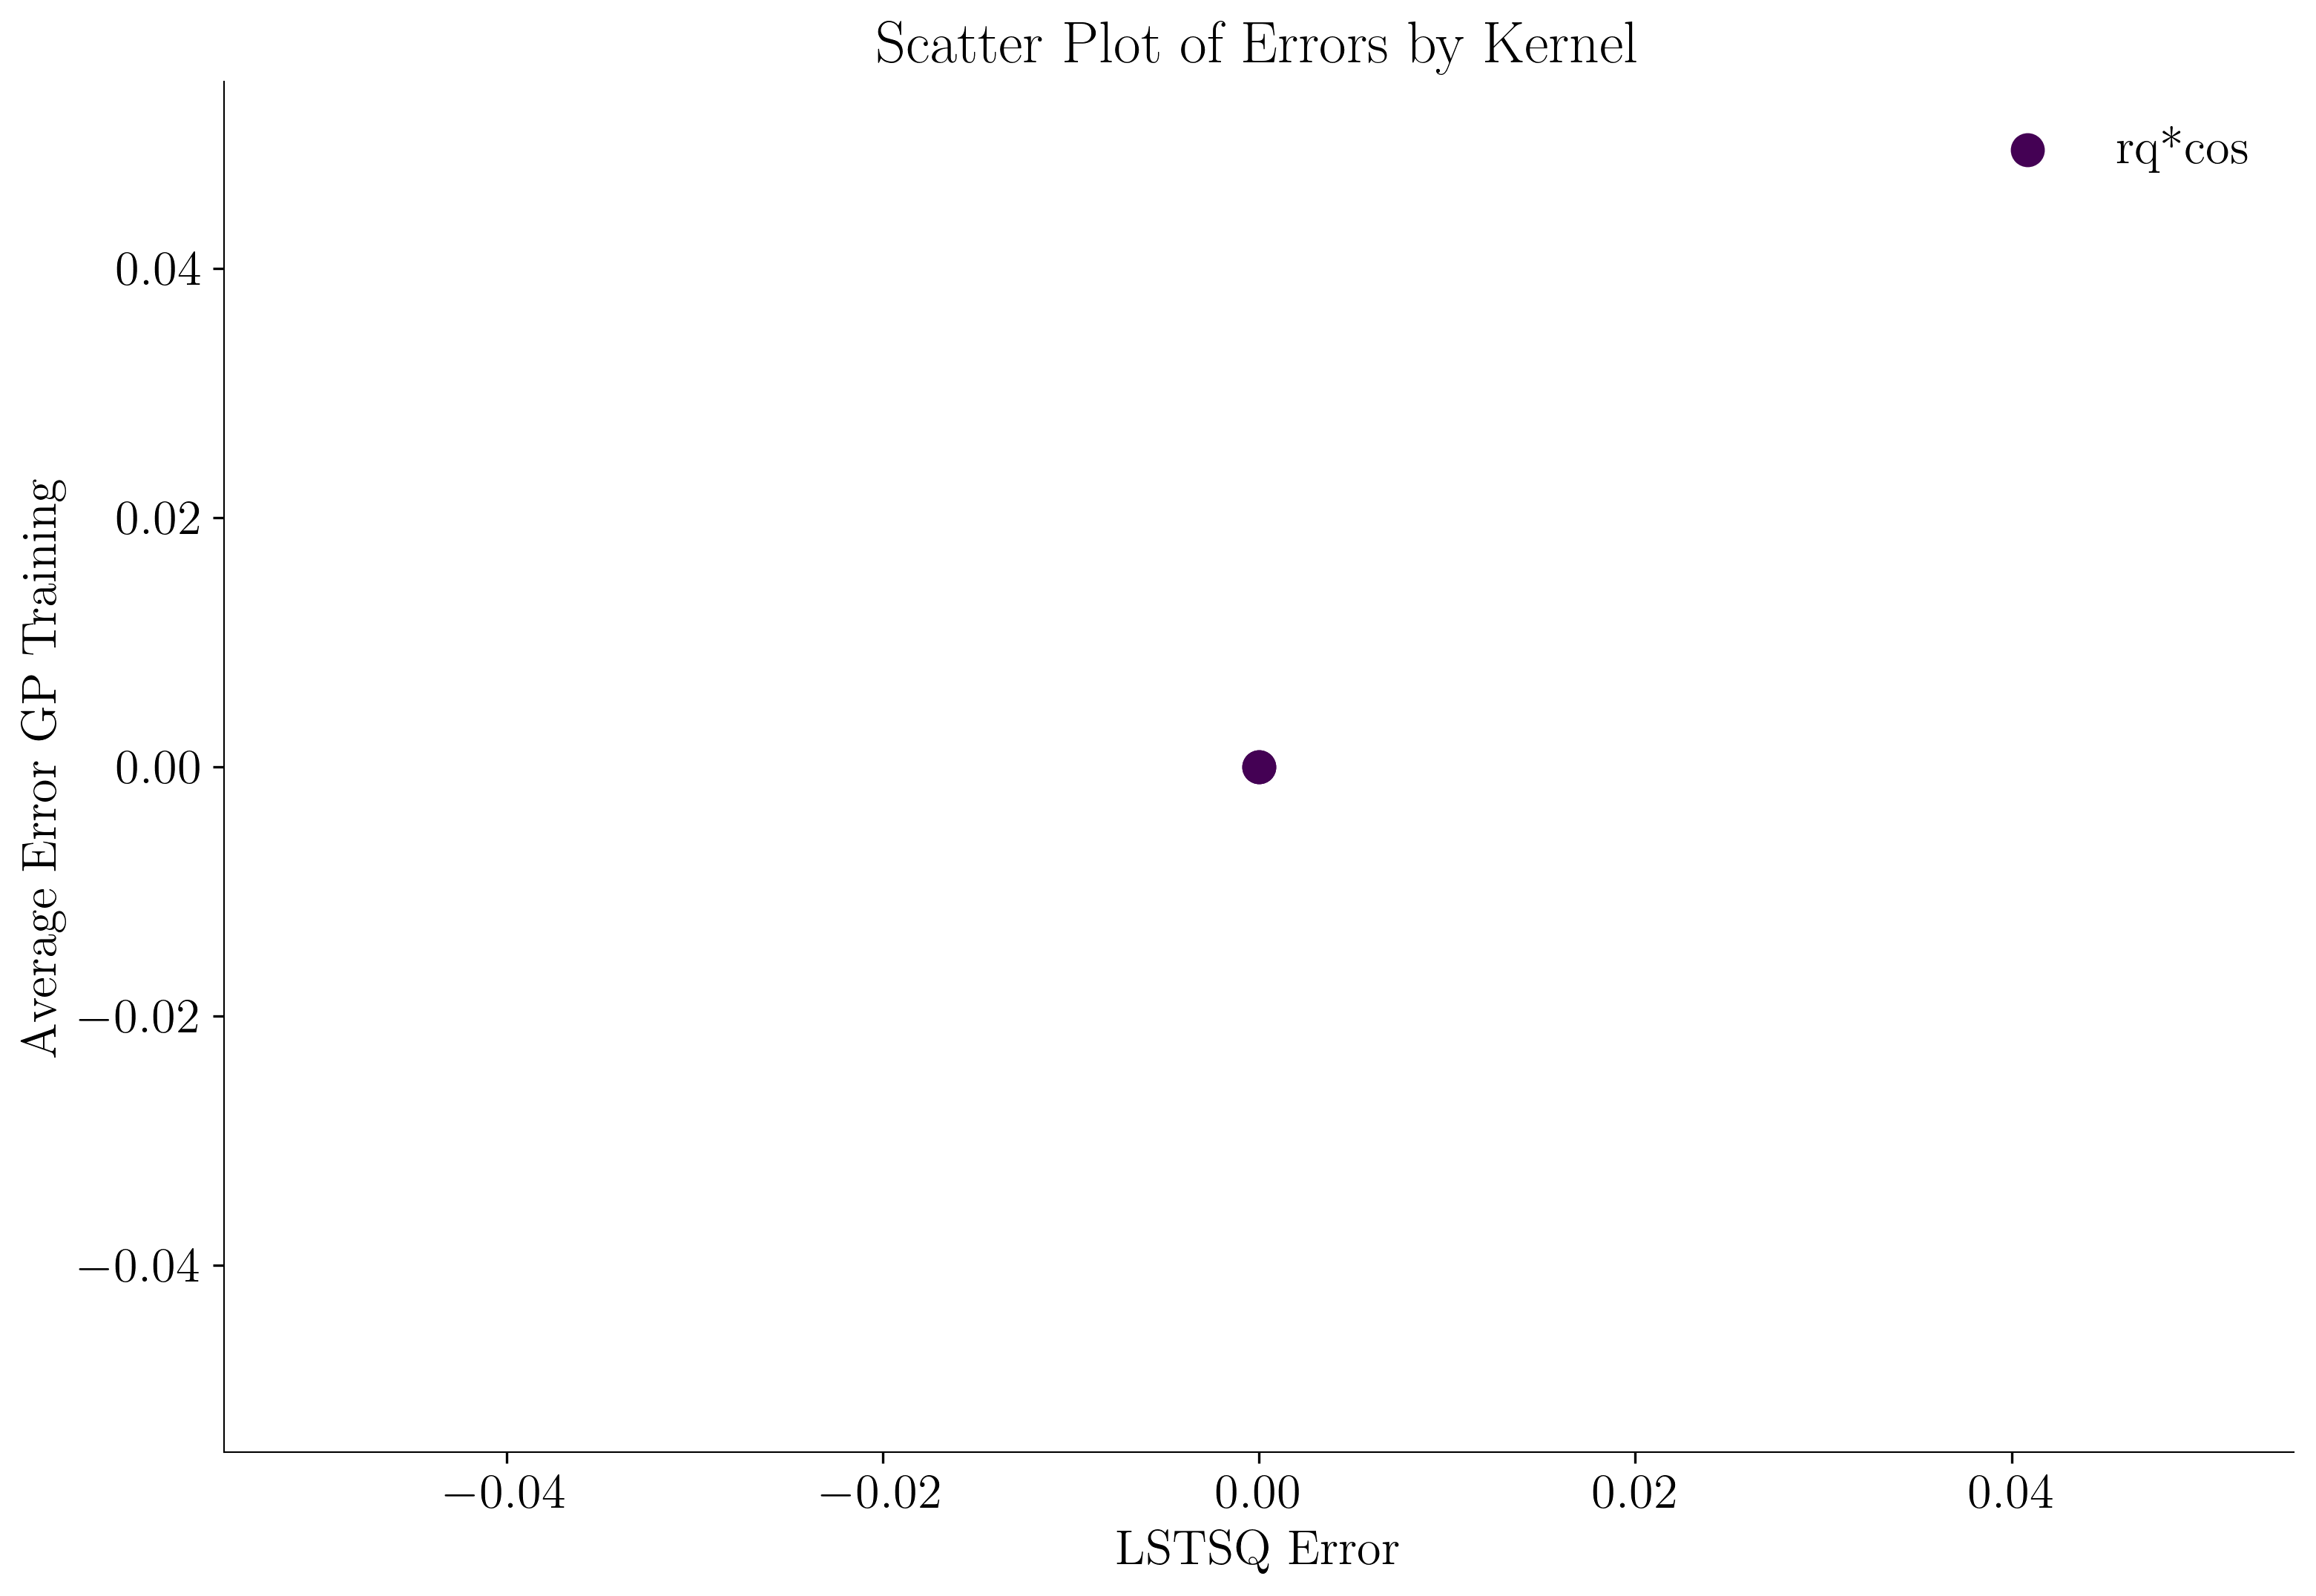

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a dictionary to group the errors by kernel name.
data_by_kernel = {}
for kernel, posterior, training in results:
    if kernel not in data_by_kernel:
        data_by_kernel[kernel] = {'posterior': [], 'training': []}
    data_by_kernel[kernel]['posterior'].append(posterior)
    data_by_kernel[kernel]['training'].append(np.array(training).mean())

# Create a new figure and axis
fig, ax = plt.subplots()

# Generate a colormap with as many unique colors as kernels
kernel_names = list(data_by_kernel.keys())
colors = plt.cm.viridis(np.linspace(0, 1, len(kernel_names)))

# Plot each group's points with the corresponding color
for idx, kernel in enumerate(kernel_names):
    ax.scatter(data_by_kernel[kernel]['posterior'],
               data_by_kernel[kernel]['training'],
               color=colors[idx],
               label=kernel,
               s=100)  # s sets the size of the markers

# Label the axes and set a title
ax.set_xlabel("LSTSQ Error")
ax.set_ylabel("Average Error GP Training")
ax.set_title("Scatter Plot of Errors by Kernel")

# Add a legend to identify the kernel groups
ax.legend()

# Display the plot
plt.savefig("scatter_errors.pdf")
plt.show()


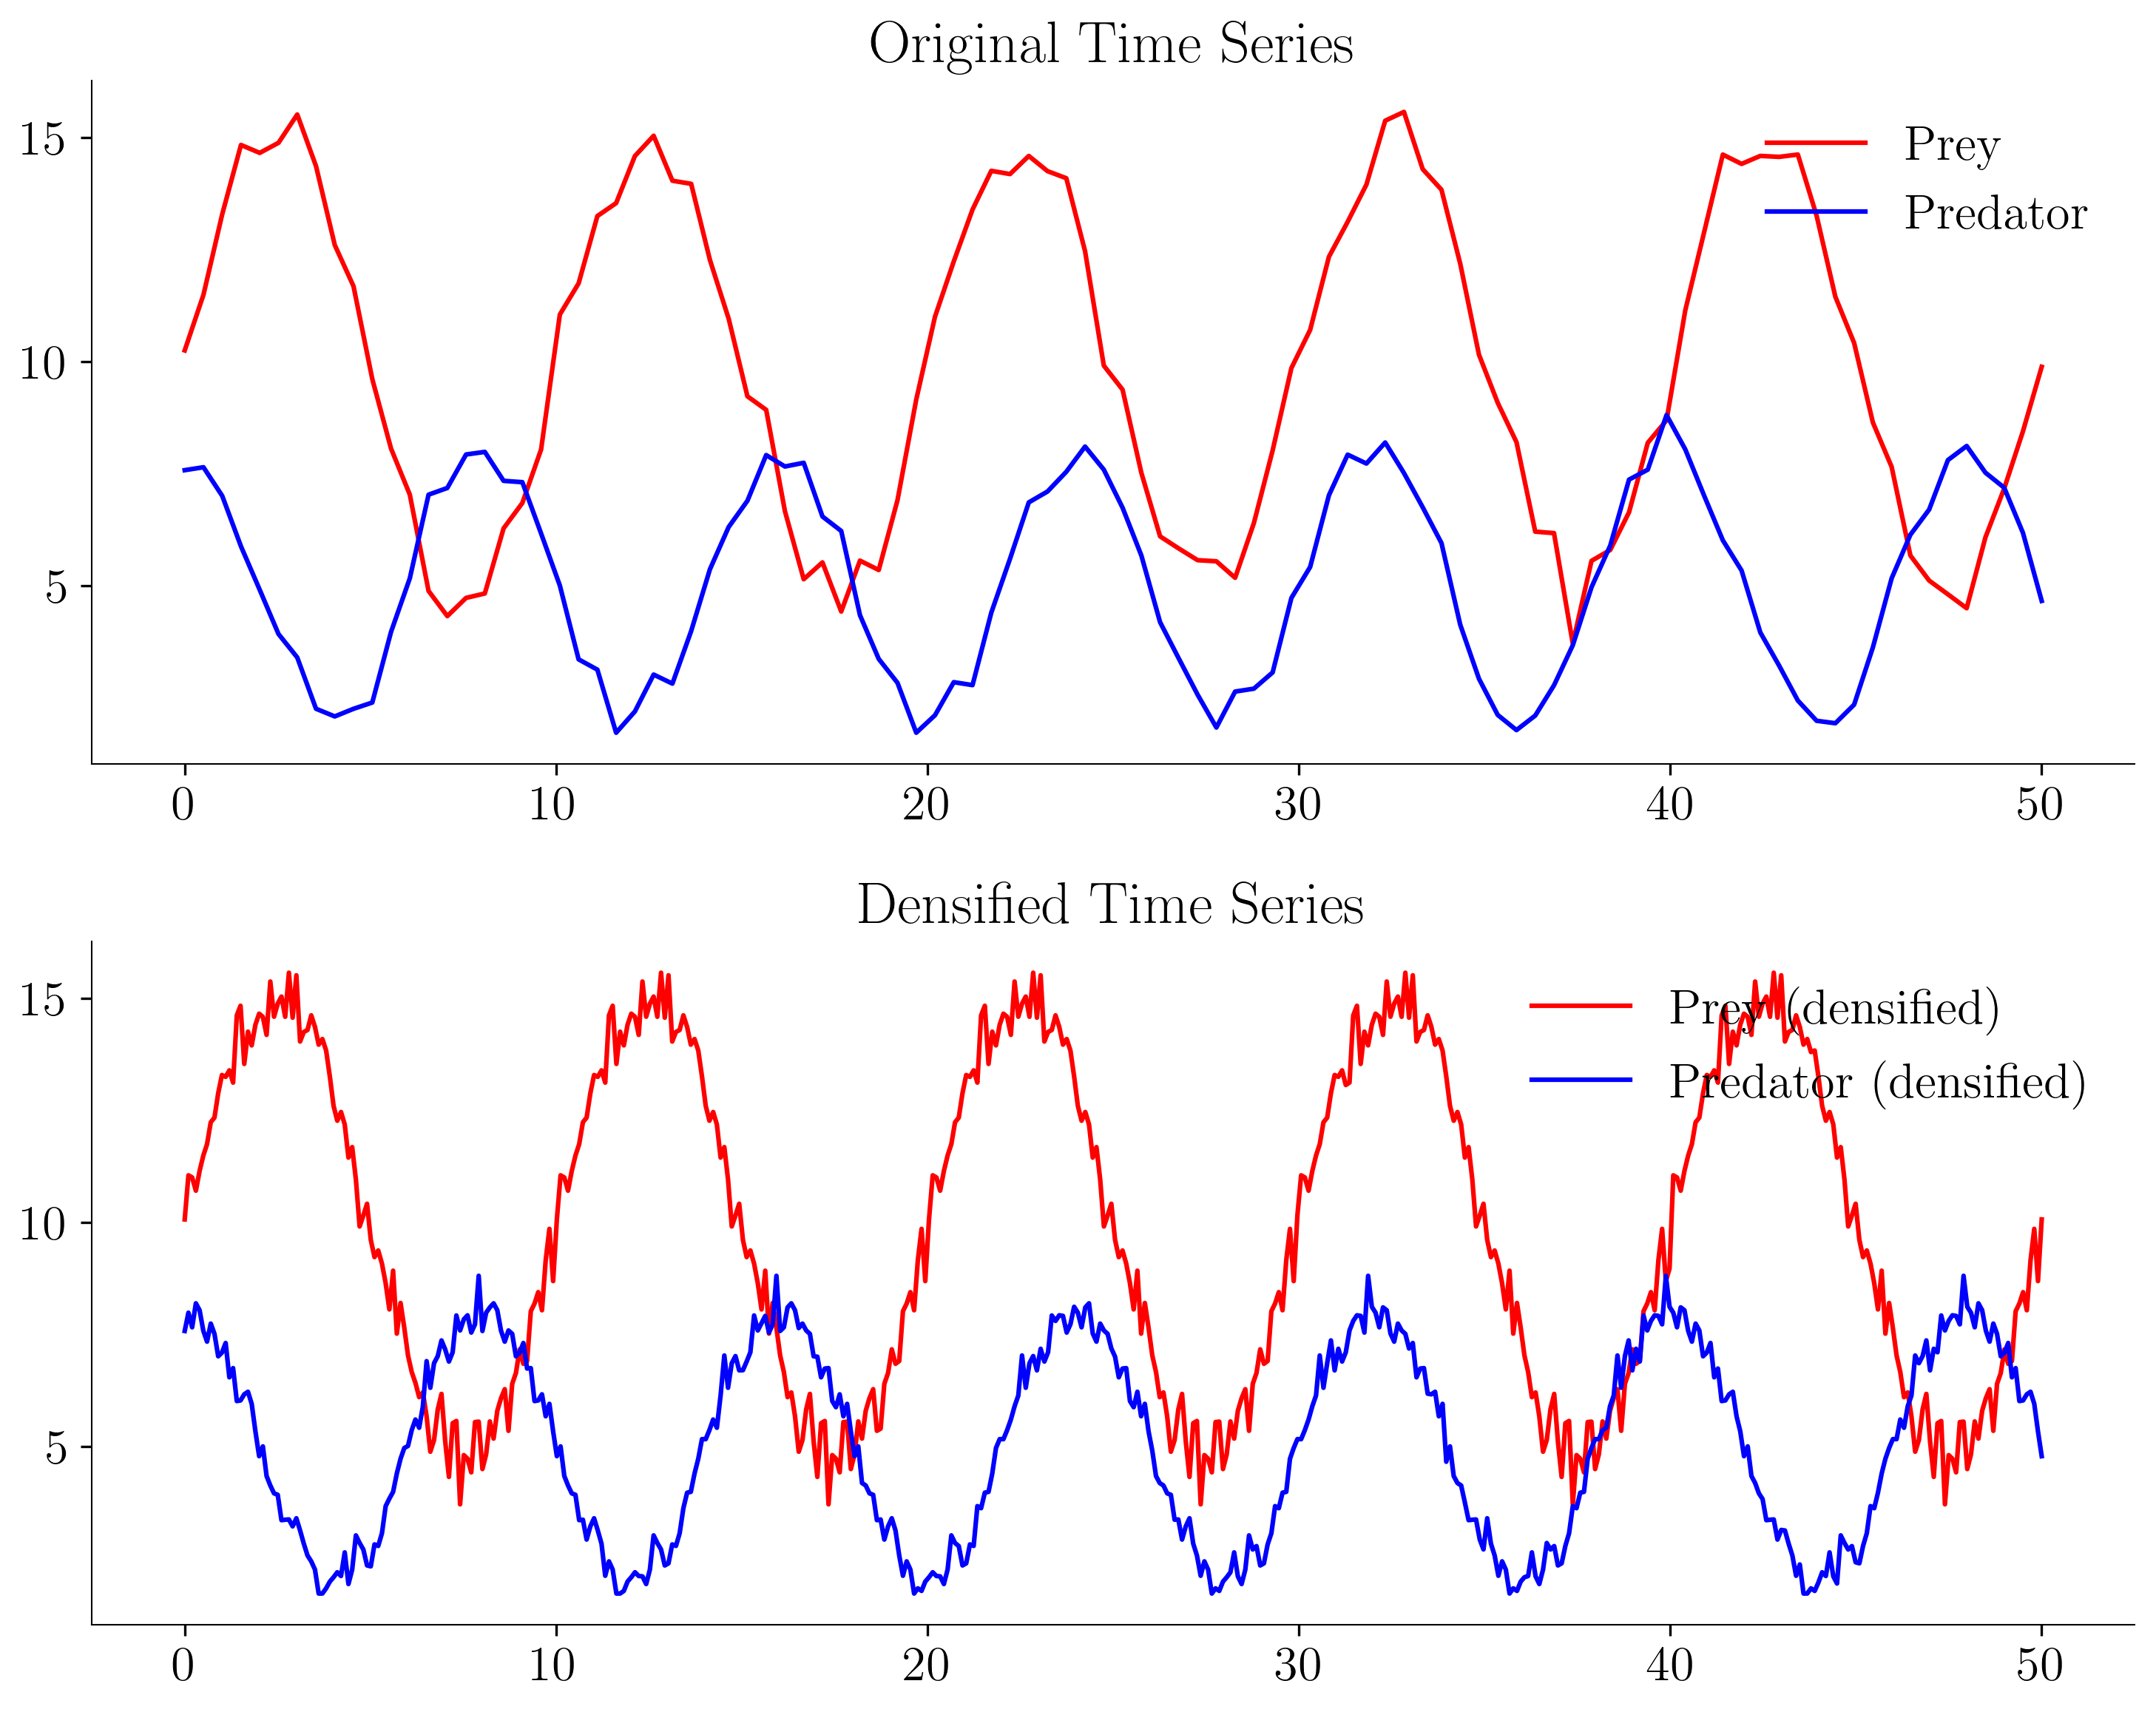

In [ ]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

def densify_time_series(time_sampled, snapshots_sampled, periods, densification_factor=5):
    """
    Densify time series data from Lotka-Volterra simulation using known periods.
    
    Parameters:
    -----------
    time_sampled : list of numpy arrays
        List containing time points for each variable (prey, predator)
    snapshots_sampled : list of numpy arrays
        List containing corresponding values for each variable
    periods : tuple
        Tuple (x, y) containing the periods of prey (x) and predator (y)
    densification_factor : int
        Factor by which to increase the density of the time series
        
    Returns:
    --------
    dense_time : list of numpy arrays
        Densified time points for each variable
    dense_snapshots : list of numpy arrays
        Densified values for each variable
    """
    dense_time = []
    dense_snapshots = []
    
    # Process each variable (prey and predator)
    for i, (time, snapshots, period) in enumerate(zip(time_sampled, snapshots_sampled, periods)):
        # Get the time range
        t_min, t_max = time.min(), time.max()
        
        # Create a denser time grid
        dense_t = np.linspace(t_min, t_max, len(time) * densification_factor)
        
        # Initialize the dense snapshots array
        dense_s = np.zeros_like(dense_t)
        
        # Create an interpolation function for the original data
        interp_func = interp1d(time, snapshots, kind='cubic', fill_value='extrapolate')
        
        # Fill the dense array using interpolation
        for j, t in enumerate(dense_t):
            # Find the phase within the period
            phase = t % period
            
            # Find all points in the original time series with the same phase (within tolerance)
            tolerance = period / (len(time) * 2)  # Reasonable tolerance
            matching_indices = np.where(np.abs((time % period) - phase) < tolerance)[0]
            
            if len(matching_indices) > 0:
                # Average the values at matching phases
                matching_values = snapshots[matching_indices]
                dense_s[j] = np.mean(matching_values)
            else:
                # If no matching phases found, use interpolation
                dense_s[j] = interp_func(t)
        
        dense_time.append(dense_t)
        dense_snapshots.append(dense_s)
    
    return dense_time, dense_snapshots

def visualize_densification(time_sampled, snapshots_sampled, dense_time, dense_snapshots):
    """
    Visualize the original and densified time series
    """
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))
    
    # Original data
    axes[0].plot(time_sampled[0], snapshots_sampled[0], 'r-', label='Prey')
    axes[0].plot(time_sampled[1], snapshots_sampled[1], 'b-', label='Predator')
    axes[0].set_title('Original Time Series')
    axes[0].legend()
    
    # Densified data
    axes[1].plot(dense_time[0], dense_snapshots[0], 'r-', label='Prey (densified)')
    axes[1].plot(dense_time[1], dense_snapshots[1], 'b-', label='Predator (densified)')
    axes[1].set_title('Densified Time Series')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# Example usage
# This is an example - you would replace with your actual data
# Simulate some Lotka-Volterra data with noise
np.random.seed(42)

# Generate sample data
def lotka_volterra(t, periods):
    prey = 10 + 5 * np.sin(2 * np.pi * t / periods[0]) + np.random.normal(0, 0.5, size=len(t))
    predator = 5 + 3 * np.sin(2 * np.pi * t / periods[1] + np.pi/2) + np.random.normal(0, 0.3, size=len(t))
    return prey, predator

# Define periods
periods = (10.0, 8.0)  # Prey has period 10, predator has period 8

# Create sample time points (sparse)
t_prey = np.linspace(0, 50, 100)
t_predator = np.linspace(0, 50, 100)

# Generate sample data
prey, predator = lotka_volterra(t_prey, periods)

# Apply the densification
time_sampled = [t_prey, t_predator]
snapshots_sampled = [prey, predator]

dense_time, dense_snapshots = densify_time_series(time_sampled, snapshots_sampled, periods, densification_factor=5)

# Visualize the results
visualize_densification(time_sampled, snapshots_sampled, dense_time, dense_snapshots)